In [2]:
import os
import numpy as np
import fitsio
from astropy.io import fits
from astropy.table import Table
from tqdm import tqdm
import math
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
sga2020 = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', hdu=1)
df2020 = sga2020.to_pandas()
df2020 = df2020.rename(columns={"RA": "Target_RA", "DEC": "Target_DEC", "SGA_ID": "TargetID"})
df2020[:10].to_csv("/pscratch/sd/q/qshimp/SGA2020-data/sga2020_test.csv")
df2020

,TargetID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,...,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
0,2,b'SGA-2020 2',b'PGC1283207',1283207,228.377086,5.423202,b'S?',152.199997,0.363078,0.724436,...,0.264044,0.345595,3.303355,0.003811,15.195567,0.298264,0.300107,3.233377,0.011724,0
1,3,b'SGA-2020 3',b'PGC1310416',1310416,202.544438,6.934594,b'Sc',159.259995,0.401791,0.781628,...,0.876432,0.273606,2.499542,0.493439,15.235263,1.309869,0.178668,2.175050,0.203912,0
2,4,b'SGA-2020 4',b'SDSSJ145059.93+135143.0',4435547,222.749787,13.861911,b'S?',44.570000,0.333426,0.663743,...,0.488582,0.278250,3.214446,1.373326,16.807674,0.517704,0.322646,2.900518,1.805409,0
3,7,b'SGA-2020 7',b'PGC1742504',1742504,182.088808,25.602276,b'Sbc',84.970001,0.548277,0.251189,...,0.765731,0.522855,2.304599,0.006013,15.191324,1.040820,0.329563,2.152033,0.004725,0
4,18,b'SGA-2020 18',b'2MASXJ12340801+4535444',3550748,188.533553,45.595643,b'E',168.649994,0.530884,0.695024,...,0.324728,1.743924,2.177483,0.023486,15.124181,0.165473,1.469468,3.394879,0.028654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383615,5005230,b'SGA-2020 5005230',b'DR8-0774m270-618',-1,77.397511,-27.106348,b'PSF',0.000000,0.332000,1.000000,...,0.231687,0.219425,3.111871,0.016901,16.022186,0.241948,0.201020,3.134553,0.011278,0
383616,5005238,b'SGA-2020 5005238',b'DR8-3541p242-2263',-1,354.025406,24.266276,b'PSF',0.000000,0.553000,1.000000,...,0.241669,0.313603,2.891678,0.068157,15.030018,0.215990,0.324286,2.999769,0.032022,0
383617,5005241,b'SGA-2020 5005241',b'DR8-3598p237-618',-1,359.778524,23.672069,b'PSF',0.000000,0.647000,1.000000,...,0.150522,0.867359,3.746000,0.005017,15.713827,0.251672,0.725019,3.094475,0.004562,0
383618,5005244,b'SGA-2020 5005244',b'DR8-1933p245-3598',-1,193.433580,24.573039,b'PSF',0.000000,0.508000,1.000000,...,8809.708984,0.000040,0.644355,0.112737,15.642013,9365.626953,0.000035,0.740361,0.139232,0


In [100]:
sgaBeta2025 = Table.read('/global/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/SGA2025-beta-parent-refcat-v1.6.kd.fits', hdu = 1)
df2025 = sgaBeta2025.to_pandas()
df2025.rename(columns={"ra": "Target_RA", "dec": "Target_DEC", "ref_id": "TargetID"}, inplace=True)
df2025

,Target_RA,Target_DEC,TargetID,mag,fitmode,pa,ba,diam
0,219.925802,-32.530045,4176048,17.780001,0,70.355278,0.583230,0.555508
1,219.891999,-32.342994,4176016,17.709999,0,150.428970,0.460713,0.507900
2,219.940904,-32.331298,242036,17.840000,0,134.882629,0.220731,0.682237
3,220.209215,-32.010931,243654,18.040001,0,91.798492,0.703881,0.507167
4,220.362323,-31.994911,4257822,15.400000,0,10.682078,0.616908,1.066838
...,...,...,...,...,...,...,...,...
470620,30.146677,28.225196,5005050,12.831638,0,162.803253,0.342439,3.757807
470621,30.867045,28.274770,4957379,16.096416,0,84.813797,0.607179,0.527874
470622,30.360603,28.734268,4807432,14.230906,0,54.906796,0.786671,0.765473
470623,30.320490,28.836853,5054143,11.612162,0,1.327161,0.183276,10.501398


In [101]:
# Add column recording bins
# Define 4 equal-sized bin edges from 0 to diamMax and a largest bin
bins = [0, 1*diamMax, 2*diamMax, 3*diamMax, 4*diamMax, np.inf]

# Assign bin IDs (0, 1, 2, 3, 4) based on the ranges
df2025['bin_id'] = pd.cut(df2025['diam'], bins=bins, labels=False, include_lowest=True) + 1
bigs = df2025[df2025['bin_id'] == 5]
df2025 = df2025[df2025['bin_id'] != 5]
bigs

,Target_RA,Target_DEC,TargetID,mag,fitmode,pa,ba,diam,bin_id
165,217.330769,-33.455154,3145667,12.982000,0,18.822403,0.699676,4.224735,5
356,217.454574,-29.748543,3145673,14.018000,0,69.956810,0.605586,3.930543,5
358,217.378352,-29.684686,3145671,15.576000,0,49.561481,0.241062,2.823520,5
453,215.142099,-29.241798,3145583,12.819000,0,153.832764,0.682749,5.227547,5
552,214.765699,-34.853779,3145563,15.429000,0,45.973919,0.147689,2.873812,5
...,...,...,...,...,...,...,...,...,...
470413,29.625201,25.360103,4860257,14.236000,0,102.398438,0.650145,2.667365,5
470426,30.906859,24.075283,5019336,13.133943,0,124.301544,0.741498,2.954888,5
470448,30.964394,25.925252,4908182,14.471000,0,37.320919,0.841658,3.253443,5
470620,30.146677,28.225196,5005050,12.831638,0,162.803253,0.342439,3.757807,5


In [137]:
PIX_SCALE       = 0.262       # arcsec/pixel for Legacy Surveys
CUTOUT_SIZE_PIX = 152         # fixed 152x152 cutouts
scale = 1 # Manually adjust this to change allowed galaxy size
diamMax = scale*PIX_SCALE*CUTOUT_SIZE_PIX/60 # max diameter in arcmin
print(f"Cutout length/height: {diamMax * 60} arcsec")

# Create separate tables for each bin 
imgBins = []
for i in range(0, 4, 1):
    imgBins.append(df2025[(df2025['diam'] > i*diamMax) & (df2025['diam'] <= (i+1)*diamMax)])
    print(f"{len(imgBins[i])} targets in sample {i}")

Cutout length/height: 39.824 arcsec
216313 targets in sample 0
214199 targets in sample 1
27788 targets in sample 2
6852 targets in sample 3


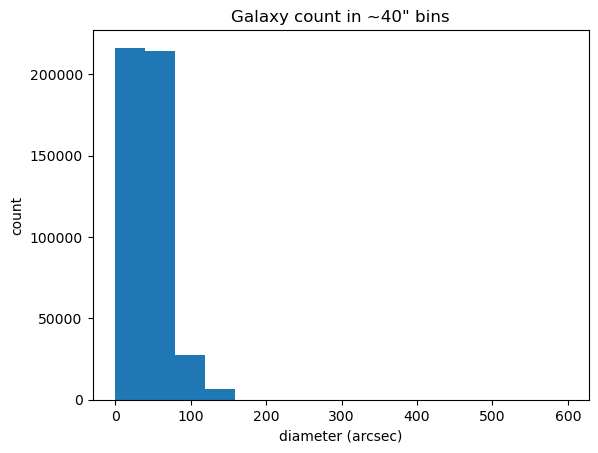

In [103]:
plt.figure()
plt.hist(60*df2025["diam"], bins=np.arange(0,600,diamMax*60))
# plt.yscale('log')
plt.xlabel("diameter (arcsec)")
plt.ylabel("count")
plt.title("Galaxy count in ~40\" bins") 
plt.savefig("/pscratch/sd/q/qshimp/SGA2025-data/plots/cutout_size_bins.png")
plt.show()

In [53]:
#for i in range(len(imgBins)):
#    plt.figure()
 #   plt.hist(60*imgBins[i]["diam"], bins=np.arange(0,600,diamMax*60))
    # plt.yscale('log')
   # plt.title("Number vs Bin size")
    #plt.xlabel("diameter (arcsec)")
 #   plt.ylabel("count")
  #  plt.show()

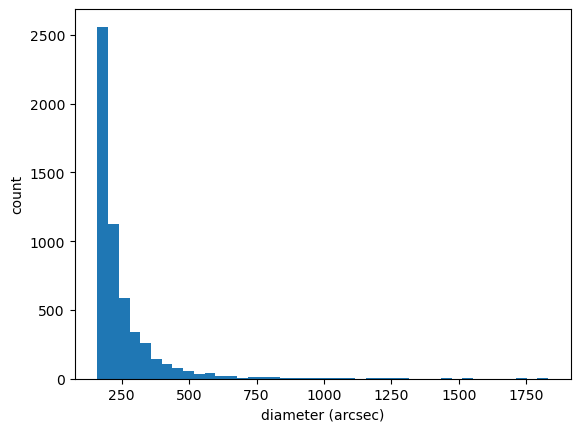

In [128]:
plt.figure()
plt.hist(60*bigs["diam"], bins=np.arange(diamMax*4*60,diamMax*47*60,diamMax*60))
# plt.yscale('log')
plt.xlabel("diameter (arcsec)")
plt.ylabel("count")
plt.show()

In [130]:
len(bigs)

5473

# Testing Questions

1. Does galaxy image size affect the accuracy of the sorter?
2. If so, how much should the galaxy fill the image for ideal accuracy?
3. How large or small can a galaxy appear to give good enough results?

These questions cannot be answered until we can run the samples through the sorter.
For now, I will apply evenly sized bins

In [139]:
imgBins[0]
len(imgBins)

4

In [140]:
extrema = pd.DataFrame()
for i in range(len(imgBins)):
    minDex = np.argmin(imgBins[i]['diam'])
    maxDex = np.argmax(imgBins[i]['diam'])
    extrema = pd.concat([extrema, imgBins[i].iloc[[minDex]]], ignore_index=True)
    extrema = pd.concat([extrema, imgBins[i].iloc[[maxDex]]], ignore_index=True)
extrema.to_csv("/pscratch/sd/q/qshimp/SGA2025-data/SGA2025_binExtrema.csv")
extrema

,Target_RA,Target_DEC,TargetID,mag,fitmode,pa,ba,diam,bin_id
0,148.454901,68.970515,5053913,18.677000,0,65.404930,0.668017,0.033460,1
1,225.888435,21.245521,4988031,15.849301,0,5.115091,0.492500,0.663733,1
2,147.864523,0.255861,4867961,16.327436,0,14.268393,0.402736,0.663733,2
3,172.080408,77.630709,4924723,14.564694,0,39.038204,0.239404,1.327461,2
4,294.836631,-31.788603,3614287,15.760000,0,161.855560,0.856350,1.327479,3
5,207.309228,35.256997,4740592,13.173854,0,121.577972,0.565350,1.991034,3
6,48.054705,-25.304946,4765519,13.447210,0,160.625793,0.275205,1.991216,4
7,124.395838,20.903068,4827949,12.949705,0,60.745304,0.389623,2.654800,4
